In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

c:\Users\Faculty\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 201s 7ms/step - loss: 0.0053
Epoch 2/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 361s 13ms/step - loss: 0.0034
Epoch 3/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 426s 16ms/step - loss: 0.0029
Epoch 4/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 256s 10ms/step - loss: 0.0026
Epoch 5/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 222s 8ms/step - loss: 0.0024
Epoch 6/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 225s 8ms/step - loss: 0.0023
Epoch 7/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 222s 8ms/step - loss: 0.0022
Epoch 8/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 219s 8ms/step - loss: 0.0021
Epoch 9/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 252s 9ms/step - loss: 0.0021
Epoch 10/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 239s 9ms/step - loss: 0.0021
Epoch 11/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 240s 9ms/step - loss: 0.0020
Epoch 12/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 237s 9ms/step - loss: 0.0020
Epoch 13/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━ 238s 9ms/step - loss: 0.0019
Epoch 14/50
26767/26767 ━━━━━━━━━━━━━━━━━━━━

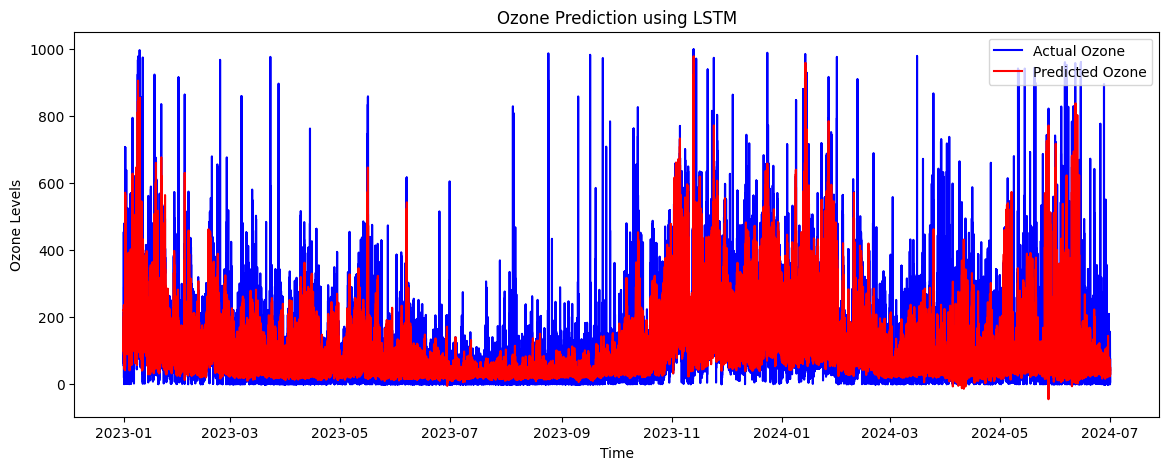

In [2]:
# Step 1: Load the dataset
data = pd.read_csv(r'C:\Users\Faculty\Desktop\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Step 2: Convert 'Time' to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Step 3: Set the Time column as the index
data.set_index('Time', inplace=True)

# Step 4: Select features and target variable
# Including PM2.5, NO2, Lat, and Lon as features
features = data[['NO2', 'Ozone', 'Lat', 'Lon','Spatial_Avg_NO2','Spatial_Avg_Ozone']]
target = data['PM2.5']

# Step 5: Normalize the features and target
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler_features.fit_transform(features)

scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target = scaler_target.fit_transform(target.values.reshape(-1, 1))

# Step 6: Create sequences for LSTM
sequence_length = 4 # Using the last 24 time steps for prediction

X, y = [], []
for i in range(sequence_length, len(scaled_features)):
    X.append(scaled_features[i-sequence_length:i])  # Previous 24 intervals of features
    y.append(scaled_target[i])                       # Ozone value to predict

X, y = np.array(X), np.array(y)

# Reshape X to be [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))  # Shape: (samples, 24, 4)

# Step 7: Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.2))  # Optional dropout to reduce overfitting
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Step 8: Train the model
model.fit(X, y, epochs=50, batch_size=32)

# Step 9: Make predictions
predicted_ozone = model.predict(X)

# Rescale predictions back to original range
predicted_ozone = scaler_target.inverse_transform(predicted_ozone)
actual_ozone = scaler_target.inverse_transform(y.reshape(-1, 1))

# Step 10: Calculate evaluation metrics
mae = mean_absolute_error(actual_ozone, predicted_ozone)
mse = mean_squared_error(actual_ozone, predicted_ozone)
r2 = r2_score(actual_ozone, predicted_ozone)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared (R²): {r2}')

# Step 11: Plot actual vs predicted Ozone levels
plt.figure(figsize=(14, 5))
plt.plot(data.index[sequence_length:], actual_ozone, label='Actual Ozone', color='blue')
plt.plot(data.index[sequence_length:], predicted_ozone, label='Predicted Ozone', color='red')
plt.title('Ozone Prediction using LSTM')
plt.xlabel('Time')
plt.ylabel('Ozone Levels')
plt.legend()
plt.show()


In [3]:
# Load the dataset
all_available = pd.read_csv(r'D:\Manoj_Honors\RF_csv\all_available(t-1)_with_spatial.csv')

# Prepare the feature set and target variable
X = all_available[['Time', 'Lat','Lon','NO2','PM2.5','Average_NO2_t-1','Average_PM2.5_t-1']]
y = all_available['Ozone']

# Convert 'Time' to numeric if it's in datetime format
X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds

# Initialize the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=12)

# Initialize KFold for cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# Prepare lists to store scores for each fold
mse_scores = []
mae_scores = []
r2_scores = []
mape_scores = []
nrmse_scores = []

# Perform cross-validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit the model on the training data
    rf.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = rf.predict(X_test)

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    nrmse = np.sqrt(mse) / (y_test.max() - y_test.min())

    mse_scores.append(mse)
    mae_scores.append(mae)
    r2_scores.append(r2)
    mape_scores.append(mape)
    nrmse_scores.append(nrmse)

# Calculate mean and standard deviation for each metric
mean_mse = np.mean(mse_scores)
std_mse = np.std(mse_scores)
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)
mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)
mean_mape = np.mean(mape_scores)
std_mape = np.std(mape_scores)
mean_nrmse = np.mean(nrmse_scores)
std_nrmse = np.std(nrmse_scores)

# Print evaluation metrics
print(f"Mean Squared Error: {round(mean_mse, 2)} ± {round(std_mse, 2)}")
print(f"Mean Absolute Error: {round(mean_mae, 2)} ± {round(std_mae, 2)}")
print(f"R^2 Score: {round(mean_r2, 2)} ± {round(std_r2, 2)}")
print(f"Mean Absolute Percentage Error: {round(mean_mape, 2)}% ± {round(std_mape, 2)}%")
print(f"Normalized RMSE: {round(mean_nrmse, 4)} ± {round(std_nrmse, 4)}")

import joblib
model_output_path = r'D:\Manoj_Honors\random_forest_model_Ozone.joblib'
joblib.dump(rf, model_output_path)

print(f"Model saved to {model_output_path}")




C:\Users\Faculty\AppData\Local\Temp\ipykernel_2000\991443163.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Time'] = pd.to_datetime(X['Time'], errors='coerce').astype('int64') // 10**9  # Convert to seconds


Mean Squared Error: 225.64 ± 1.93
Mean Absolute Error: 8.45 ± 0.01
R^2 Score: 0.81 ± 0.0
Mean Absolute Percentage Error: 104.39% ± 1.3%
Normalized RMSE: 0.0751 ± 0.0003
Model saved to D:\Manoj_Honors\random_forest_model_Ozone.joblib


In [2]:
# Load the trained model
rf_model = joblib.load(r'D:\Manoj_Honors\random_forest_model_NO2.joblib')

# Check the type of the loaded model
print(f"Loaded model type: {type(rf_model)}")


Loaded model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [2]:
import pandas as pd
import joblib

# File paths
model_path = r"D:\Manoj_Honors\random_forest_model_Ozone.joblib"
input_csv_path = r'D:\Manoj_Honors\Imputed_Predictions(NO2).csv'
output_csv_path = r"D:\Manoj_Honors\Imputed_Predictions(NO2,Ozone).csv"

# Load the model
with open(model_path, 'rb') as model_file:
    rf_model = joblib.load(model_file)

# Load the input data
df = pd.read_csv(input_csv_path)

# Check the required columns
required_columns = ['Time', 'Lat','Lon','NO2','PM2.5','Average_NO2_t-1','Average_PM2.5_t-1','Ozone']
for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# Identify rows where both PM2.5 and NO2 are missing, but Ozone is available
mask_missing_pm_no2 = df['NO2'].notna() & df['Ozone'].isna() & df['PM2.5'].notna()

# Count such rows
missing_rows_count = mask_missing_pm_no2.sum()
print(f"Number of rows with missing O3 :  {missing_rows_count}")

# Filter the rows that meet the condition
rows_to_impute = df[mask_missing_pm_no2]

# Prepare the features for imputation (Time, Lat, Lon, Ozone, Average_Ozone_t-1, etc.)
X_to_impute = rows_to_impute[['Time', 'Lat','Lon','NO2','PM2.5','Average_NO2_t-1','Average_PM2.5_t-1']]

# Convert 'Time' to seconds since epoch for prediction input
X_to_impute.loc[:, 'Time'] = pd.to_datetime(X_to_impute['Time'], errors='coerce').astype('int64') // 10**9

# Ensure the columns are in the same order as during model training
train_columns = ['Time', 'Lat','Lon','NO2','PM2.5','Average_NO2_t-1','Average_PM2.5_t-1']
X_to_impute = X_to_impute[train_columns]

# Impute the missing values using the model
imputed_values = rf_model.predict(X_to_impute)

# Assign the imputed values to the 'NO2' column in the original DataFrame
df.loc[mask_missing_pm_no2, 'Ozone'] = imputed_values

# Save the updated dataframe with imputed values to a new CSV
df.to_csv(output_csv_path, index=False)

print(f"Imputed rows and saved the updated data to {output_csv_path}")


Number of rows with missing O3 :  59426
Imputed rows and saved the updated data to D:\Manoj_Honors\Imputed_Predictions(NO2,Ozone).csv


In [1]:
import pandas as pd
df = pd.read_csv(r'D:\Manoj_Honors\Imputed_Predictions(Univariate,Bivariate).csv')
df.isna().sum()

Time                     0
Station_ID               0
NO2                  81208
PM2.5                81208
Ozone                81208
Lat                      0
Lon                      0
Date                     0
Average_PM2.5_t-1    61823
Average_Ozone_t-1    75695
Average_NO2_t-1      54288
dtype: int64